<a href="https://colab.research.google.com/github/hsmu-jeongeun/health-infomatics/blob/main/07_Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 7주차 실습: 의사결정나무 모델 예측 체험

## 학습 목표
- 기계학습(Machine Learning)의 분류(Classification) 개념을 이해할 수 있다
- Scikit-learn으로 의사결정나무(Decision Tree) 모델을 학습시킬 수 있다
- `feature_importances_`로 예측에 중요한 변수를 확인할 수 있다

---

## 오늘의 핵심 개념: AI가 당뇨병을 예측하는 방법

> 의사결정나무는 스무고개 게임과 같음.` '혈당이 140 이상인가? → YES → BMI가 30 이상인가? → YES → 당뇨 고위험!' 처럼 질문을 연속으로 던져 최종 예측에 도달

### 병원정보시스템과 AI의 융합
- **스마트 병원:** EMR 데이터를 기반으로 AI가 질병 발생 위험도를 예측
- **CDSS(임상의사결정지원시스템):** 의사·간호사에게 AI 기반 예측 결과를 제공
- **기계학습 파이프라인:**
  1. 데이터 준비 (환자 특성 + 진단 결과)
  2. 모델 학습 (Training)
  3. 모델 평가 (Test)
  4. 새 환자에 적용 (Prediction)

### 의사결정나무의 장점
- **해석 가능성:** 어떤 조건으로 예측했는지 설명 가능 (Black-box가 아님)
- **간호사도 이해 가능:** '혈당이 높고 BMI가 높으면 당뇨 위험' 같은 규칙으로 표현

In [1]:
# 필요한 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

print('Loaded')

Loaded


## 당뇨병 예측 가상 데이터셋 생성

피마 인디언 당뇨병 데이터셋을 모사한 가상 데이터
- 원본 : [Kaggle link](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)
- 특성(Feature): 임신횟수, 혈당, 혈압, 피부두께, 인슐린, BMI, 유전지수, 나이
- 레이블(Label): 당뇨 여부 (1=당뇨, 0=정상)

In [2]:
np.random.seed(42)
n = 500  # 환자 수

# 정상 그룹 (300명)
normal_glucose = np.random.normal(95,  15, 300)
normal_bmi     = np.random.normal(26,   4, 300)
normal_age     = np.random.normal(35,   8, 300).clip(18, 70)
normal_bp      = np.random.normal(72,   8, 300)
normal_insulin = np.random.normal(80,  30, 300).clip(10, 200)
normal_skin    = np.random.normal(22,   5, 300).clip(5, 50)
normal_dpf     = np.random.normal(0.3, 0.2, 300).clip(0.05, 1.0)
normal_preg    = np.random.randint(0, 4, 300).astype(float)

# 당뇨 그룹 (200명)
diab_glucose   = np.random.normal(155, 25, 200)
diab_bmi       = np.random.normal(34,   5, 200)
diab_age       = np.random.normal(50,  10, 200).clip(25, 75)
diab_bp        = np.random.normal(80,  10, 200)
diab_insulin   = np.random.normal(140, 60, 200).clip(10, 400)
diab_skin      = np.random.normal(30,   7, 200).clip(5, 60)
diab_dpf       = np.random.normal(0.65, 0.3, 200).clip(0.1, 2.0)
diab_preg      = np.random.randint(2, 8, 200).astype(float)

feature_names = ['임신횟수', '혈당', '혈압', '피부두께', '인슐린', 'BMI', '유전지수', '나이']

X = np.vstack([
    np.column_stack([normal_preg, normal_glucose, normal_bp, normal_skin, normal_insulin, normal_bmi, normal_dpf, normal_age]),
    np.column_stack([diab_preg,   diab_glucose,   diab_bp,   diab_skin,   diab_insulin,   diab_bmi,   diab_dpf,   diab_age])
])
y = np.array([0]*300 + [1]*200)

# 섞기
idx = np.random.permutation(n)
X, y = X[idx], y[idx]

df = pd.DataFrame(np.round(X, 1), columns=feature_names)
df['당뇨여부'] = y

print(f'데이터셋: {n}명')
print(f'당뇨 환자: {y.sum()}명, 정상: {n - y.sum()}명')
df.head()

데이터셋: 500명
당뇨 환자: 200명, 정상: 300명


,임신횟수,혈당,혈압,피부두께,인슐린,BMI,유전지수,나이,당뇨여부
0,1.0,75.1,74.0,16.2,97.1,27.7,0.3,24.7,0
1,3.0,167.3,86.4,22.8,134.1,32.9,0.9,50.4,1
2,7.0,193.3,77.4,43.7,34.9,32.0,0.7,58.2,1
3,2.0,112.4,81.2,11.4,83.6,23.2,0.4,55.5,0
4,3.0,114.6,68.3,29.1,80.1,25.9,0.2,24.8,0


## 데이터 분할 — 훈련 세트 vs 테스트 세트

> 시험을 앞두고 '예상문제집(훈련 세트)'으로 공부하고, '실제 시험(테스트 세트)'으로 실력을 측정하는 것과 같음

In [3]:
# 훈련(80%) / 테스트(20%) 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'훈련 세트: {len(X_train)}명')
print(f'테스트 세트: {len(X_test)}명')

훈련 세트: 400명
테스트 세트: 100명


## 의사결정나무 모델 학습

In [4]:
# =====================
# 수정해 보세요!
# =====================
max_depth = 5  # 나무의 최대 깊이 (3~10 사이로 변경해보세요)
# =====================

# 모델 생성 및 학습
model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
model.fit(X_train, y_train)

# 테스트 세트 평가
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f'Train Finished')
print(f'모델 정확도 (Accuracy): {accuracy:.4f} ({accuracy*100:.1f}%)')
print()
print(classification_report(y_test, y_pred, target_names=['정상', '당뇨']))

Train Finished
모델 정확도 (Accuracy): 1.0000 (100.0%)

              precision    recall  f1-score   support

          정상       1.00      1.00      1.00        60
          당뇨       1.00      1.00      1.00        40

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



- 시각적 그래프로 트리 그리기

/usr/local/lib/python3.12/dist-packages/sklearn/tree/_export.py:673: UserWarning: Glyph 54792 (\N{HANGUL SYLLABLE HYEOL}) missing from font(s) DejaVu Sans.
  ann.update_bbox_position_size(renderer)
/usr/local/lib/python3.12/dist-packages/sklearn/tree/_export.py:673: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  ann.update_bbox_position_size(renderer)
/usr/local/lib/python3.12/dist-packages/sklearn/tree/_export.py:673: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  ann.update_bbox_position_size(renderer)
/usr/local/lib/python3.12/dist-packages/sklearn/tree/_export.py:673: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  ann.update_bbox_position_size(renderer)
/usr/local/lib/python3.12/dist-packages/sklearn/tree/_export.py:673: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  ann.update_bbox_position_size(renderer)
/usr/local/lib/

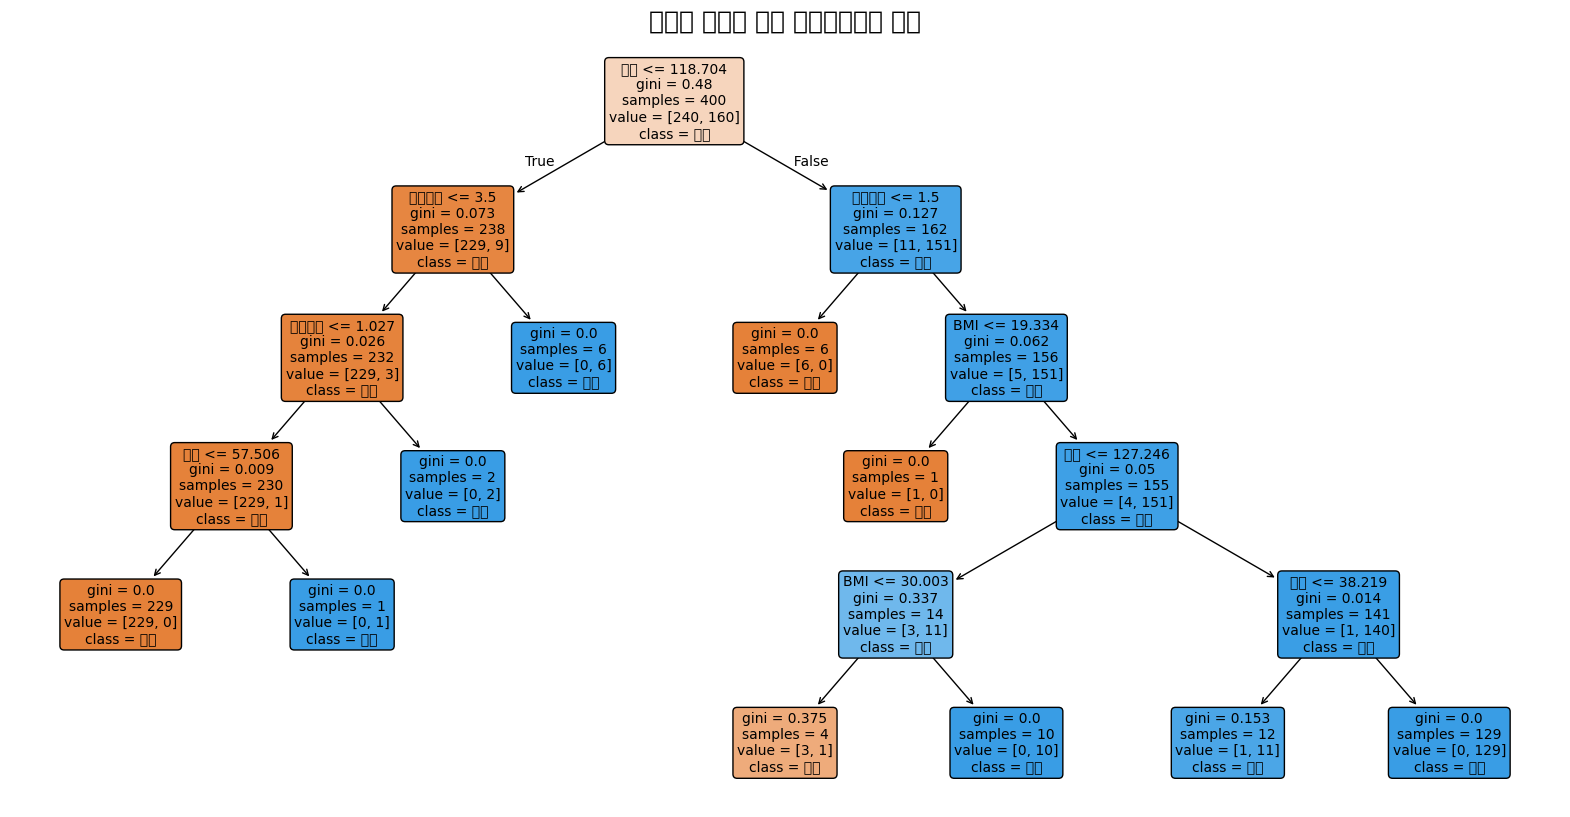

In [5]:
plt.figure(figsize=(20, 10)) # 그래프 크기 설정
plot_tree(model,
          feature_names=feature_names,  # 각 노드의 분기 기준이 되는 변수명
          class_names=['정상', '당뇨'],    # 예측할 타겟 클래스 이름
          filled=True,                  # 클래스 비율에 따라 노드 색상 칠하기
          rounded=True,                 # 노드 테두리를 둥글게
          fontsize=10)                  # 글자 크기
plt.title("학습된 당뇨병 예측 의사결정나무 구조", fontsize=18)
plt.show()

## 변수 중요도(Feature Importance) 확인

In [6]:
# feature_importances_ 출력
importances = model.feature_importances_
importance_df = pd.DataFrame({
    '변수명': feature_names,
    '중요도': importances
}).sort_values('중요도', ascending=False).reset_index(drop=True)

print('=== 변수 중요도 순위 ===')
for i, row in importance_df.iterrows():
    bar = '█' * int(row['중요도'] * 50)
    print(f'{i+1:2d}위. {row["변수명"]:8s}: {row["중요도"]:.4f}  {bar}')

most_important = importance_df.iloc[0]['변수명']
print(f'\n예측에 가장 큰 영향을 미친 변수: {most_important}')

=== 변수 중요도 순위 ===
 1위. 혈당      : 0.8230  █████████████████████████████████████████
 2위. 임신횟수    : 0.1178  █████
 3위. BMI     : 0.0270  █
 4위. 유전지수    : 0.0208  █
 5위. 나이      : 0.0114  
 6위. 혈압      : 0.0000  
 7위. 피부두께    : 0.0000  
 8위. 인슐린     : 0.0000  

예측에 가장 큰 영향을 미친 변수: 혈당


/tmp/ipykernel_986/2974594479.py:13: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_986/2974594479.py:13: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_986/2974594479.py:13: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_986/2974594479.py:13: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_986/2974594479.py:13: UserWarning: Glyph 49808 (\N{HANGUL SYLLABLE SYUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_986/2974594479.py:13: UserWarning: Glyph 47536 (\N{HANGUL SYLLABLE RIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_986/2974594479.py:13: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/

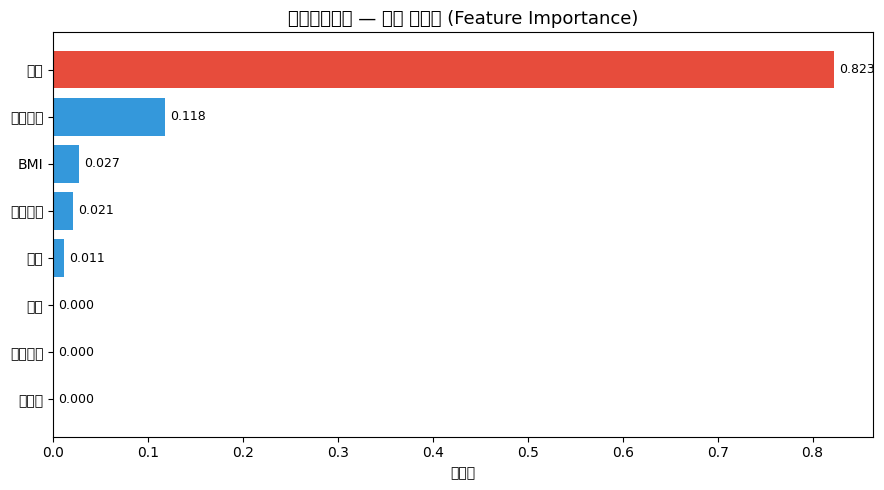

In [7]:
# 변수 중요도 시각화
fig, ax = plt.subplots(figsize=(9, 5))

colors = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(importance_df))]
bars = ax.barh(importance_df['변수명'][::-1],
               importance_df['중요도'][::-1],
               color=colors[::-1])
ax.set_title('의사결정나무 — 변수 중요도 (Feature Importance)', fontsize=13)
ax.set_xlabel('중요도')
for bar, val in zip(bars, importance_df['중요도'][::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2.,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 나의 수치로 예측해보기

In [8]:
# =====================
# 수정해 보세요! — 본인의 (가상) 건강 수치로 변경해보세요
# =====================
my_data = {
    '임신횟수': 0,    # 회
    '혈당':    105,  # mg/dL
    '혈압':     72,  # mmHg (이완기)
    '피부두께':  25,  # mm
    '인슐린':   85,  # μU/mL
    'BMI':    23.5,  # kg/m²
    '유전지수': 0.35, # 당뇨 가족력 지수
    '나이':     25   # 세
}
# =====================

my_array = np.array([[my_data[f] for f in feature_names]])
pred      = model.predict(my_array)[0]
prob      = model.predict_proba(my_array)[0]

result = '당뇨 고위험' if pred == 1 else '정상 (저위험)'
print(f'예측 결과: {result}')
print(f'당뇨 예측 확률: {prob[1]*100:.1f}%')
print(f'정상 예측 확률: {prob[0]*100:.1f}%')

예측 결과: 정상 (저위험)
당뇨 예측 확률: 0.0%
정상 예측 확률: 100.0%


---

## Canvas 퀴즈 안내

아래 코드 셀을 실행하여 나온 **단어**를 Canvas 퀴즈의 정답으로 제출하세요.

**문제:** 의사결정나무 모델 코드의 `feature_importances_`를 출력했을 때, 예측에 가장 큰 영향을 미친 **1순위 변수(Feature)의 이름**은 무엇일까요?

In [ ]:
# [실습] 아래 코드를 실행하여 나온 결과를 Canvas 퀴즈의 정답으로 제출
canvas_answer = most_important
print(f'Answer: {canvas_answer}')